In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    nthreads=4,
)
analysis_run = ds.pipeline.open(label="docs_default")
graph = analysis_run["connectivity_map"]

annotations = ds.cells.fetch("clusters", key="I")
source = annotations == "Ductal"
sink = np.isin(annotations, ["Alpha", "Beta", "Delta"])
if not source.any() or not sink.any():
    raise ValueError("Source and sink annotations must both be present")
source_sink_vector = np.zeros(len(annotations), dtype=float)
source_sink_vector[source] = -1.0 / source.sum()
source_sink_vector[sink] = 1.0 / sink.sum()

pseudotime_ref = ds.run_pseudotime_scoring(graph, ss_vec=source_sink_vector)
pseudotime = ds.load_pseudotime_scoring(pseudotime_ref)
sink_labels_ref = analysis_run["clusters"]
sink_labels = analysis_run.cells.fetch("clusters")

Downloading bucket files: 52931410 / 52931410 complete

Downloading bytes: 52931410 / 52931410 complete

In [2]:
candidate_fates = ["Alpha", "Beta", "Delta"]

# Map biological names to the run's integer sink labels. Both fetches cover
# the same cells in the same order, so positional grouping is exact.
cluster_names = np.asarray(ds.cells.fetch("clusters", key="I"))
assert len(cluster_names) == len(sink_labels)
name_by_id = (
    pd.Series(cluster_names).groupby(sink_labels).agg(lambda s: s.mode().iat[0])
)
share_by_id = (
    pd.Series(cluster_names)
    .groupby(sink_labels)
    .agg(lambda s: float((s == s.mode().iat[0]).mean()))
)
id_by_name = {}
for i, name in name_by_id.items():
    id_by_name.setdefault(name, []).append(int(i))
missing_fates = [fate for fate in candidate_fates if fate not in id_by_name]
if missing_fates:
    raise ValueError(f"Target sinks missing from dataset: {missing_fates}")
ambiguous_fates = {
    fate: id_by_name[fate] for fate in candidate_fates if len(id_by_name[fate]) != 1
}
if ambiguous_fates:
    raise ValueError(f"Ambiguous sink mapping, refine the selection: {ambiguous_fates}")
terminal_labels = [id_by_name[fate][0] for fate in candidate_fates]
print(f"Tracking differentiation potential into {len(terminal_labels)} fates: {candidate_fates}")
sink_names = {int(label): str(name_by_id.loc[label]) for label in terminal_labels}
pd.DataFrame(
    {
        "sink label": terminal_labels,
        "majority annotation": [sink_names[int(label)] for label in terminal_labels],
        "majority share": [
            round(float(share_by_id.loc[label]), 3) for label in terminal_labels
        ],
    }
)

Tracking differentiation potential into 3 fates: ['Alpha', 'Beta', 'Delta']


,sink label,majority annotation,majority share
0,3,Alpha,0.928
1,11,Beta,0.978
2,10,Delta,0.742


In [3]:
# Execute fate mapping across all three lineages.
fate_ref = ds.run_fate_mapping(
    pseudotime_ref,
    sink_labels_ref,
    sinks=terminal_labels,
)
fate = ds.load_fate_mapping(fate_ref)
{
    "artifact": fate.ref,
    "pseudotime": fate.pseudotime,
    "sink labels": fate.sink_labels,
    "valid cells": int(fate.valid.sum()),
}

{'artifact': ArtifactRef(assay='RNA', kind='fate_map', artifact_id='dccc5bd7ed7f...'),
 'pseudotime': ArtifactRef(assay='RNA', kind='pseudotime', artifact_id='00cd9b7874ca...'),
 'sink labels': (3, 11, 10),
 'valid cells': 3696}

In [4]:
valid_probabilities = fate.values[fate.valid]
probability_summary = pd.DataFrame(
    valid_probabilities,
    columns=[str(label) for label in fate.sink_labels],
)
# Theoretical check: absorbing probabilities must sum to 1.0 per cell.
probability_summary["row-sum error"] = np.abs(
    probability_summary.sum(axis=1) - 1.0
)
probability_summary.agg(["min", "median", "max"])

,3,11,10,row-sum error
min,0.000000,0.000000,0.000000,0.000000e+00
median,0.360949,0.299733,0.310332,0.000000e+00
max,1.000000,1.000000,1.000000,5.960464e-08


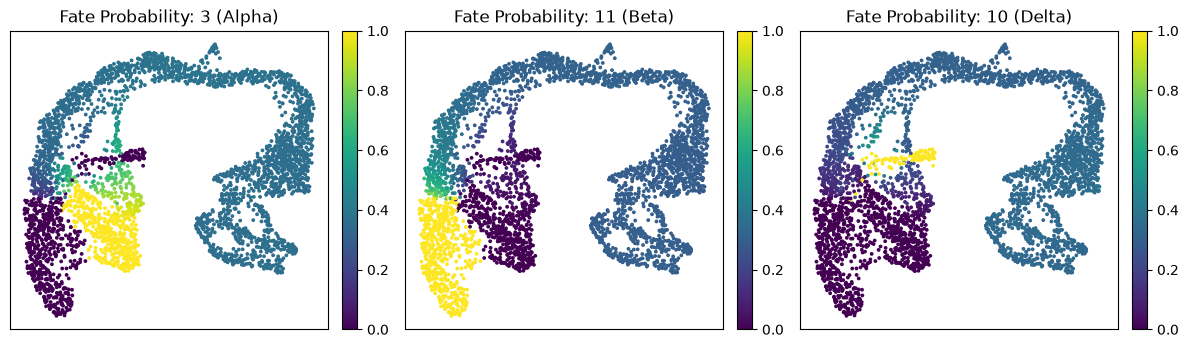

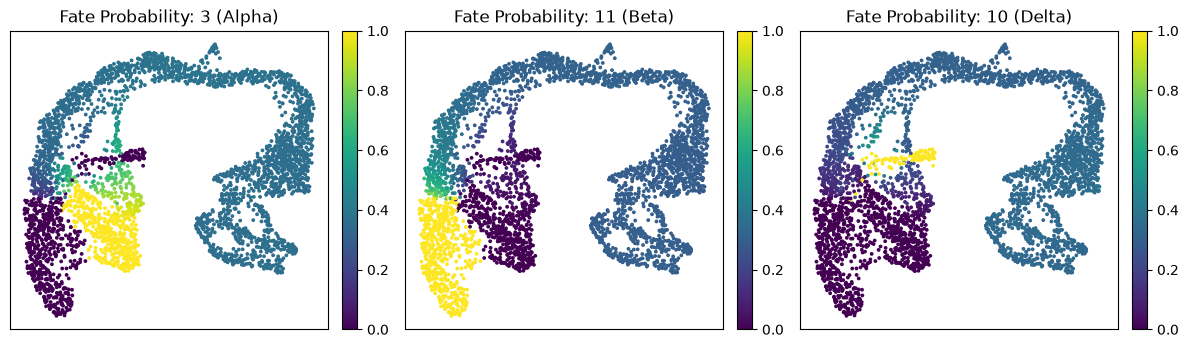

In [5]:
umap = np.asarray(ds.load_artifact(analysis_run["umap"])["values"][:])
num_sinks = len(fate.sink_labels)
figure, axes = plt.subplots(1, num_sinks, figsize=(4 * num_sinks, 3.5))
for index, label in enumerate(fate.sink_labels):
    axis = axes[index]
    points = axis.scatter(
        umap[fate.valid, 0],
        umap[fate.valid, 1],
        c=fate.values[fate.valid, index],
        cmap="viridis",
        vmin=0.0,
        vmax=1.0,
        s=3,
    )
    # Biological lineage name paired with the integer sink label.
    axis.set_title(f"Fate Probability: {label} ({sink_names[int(label)]})")
    axis.set_xticks([])
    axis.set_yticks([])
    figure.colorbar(points, ax=axis, fraction=0.046, pad=0.04)
figure.tight_layout()
figure